 **Tarea: Mejorar la imagen**





Importación de la imagen junto con su escala de gris e histograma

size =  (256, 256)


Text(0, 0.5, 'Frecuencia')

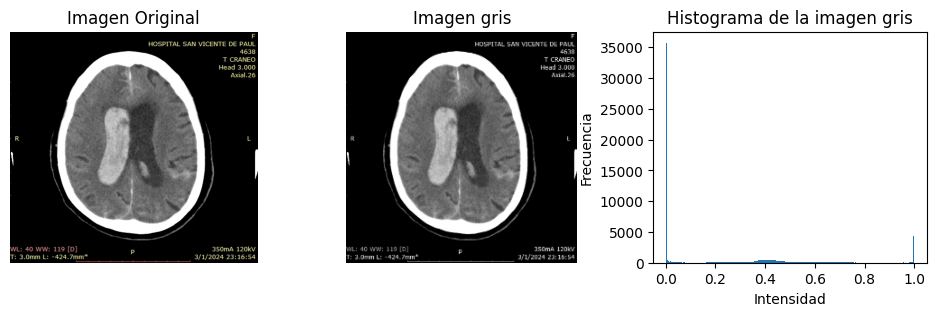

In [1]:
#Carga de la imagen
import matplotlib.pyplot as plt
from skimage.transform import resize
import numpy as np
from skimage import color,io

url = "https://github.com/gitDavidVasconez/tareas/raw/main/craneo.png"
img_original = io.imread(url)
img_gray = color.rgb2gray(img_original) #escala de grises
img = resize(img_gray, (256, 256), anti_aliasing=True).astype(np.float32)  # tamaño 256x256, valores en [0,1]  y tipo float32

# Visualización de la imagen y su histograma
print('size = ',img.shape)
plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1); plt.imshow(img_original); plt.axis('off'); plt.title("Imagen Original")
plt.subplot(1, 3, 2); plt.imshow(img,cmap='gray'); plt.axis('off'); plt.title("Imagen gris")
plt.subplot(1, 3, 3); plt.hist(img.ravel(), bins=256); plt.title("Histograma de la imagen gris")
plt.xlabel("Intensidad")
plt.ylabel("Frecuencia")


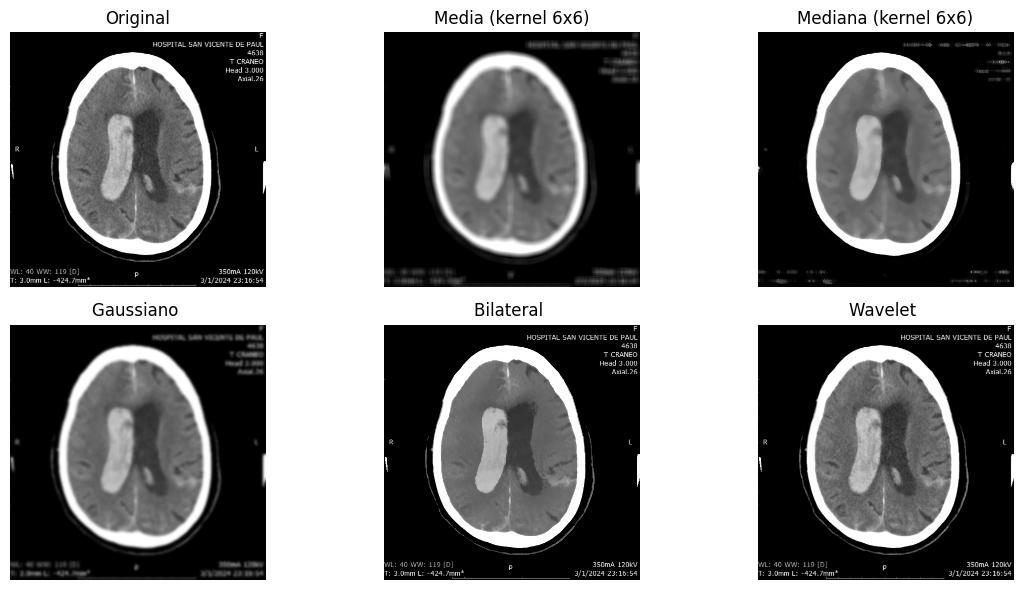

In [82]:
# Eliminación de ruido y suavizado 
from scipy.ndimage import uniform_filter, median_filter
from skimage.filters import gaussian
from skimage.restoration import denoise_bilateral, denoise_wavelet

k = 6 # tamaño del kernel (k x k)
img_mean = uniform_filter(img, size=k)      #filtro de media con kernel k x k
img_median = median_filter(img, size=k)     #filtro de mediana con kernel k x k *********** SELECCIONADA ***********
img_gauss = gaussian(img, sigma=1.2)        # Gaussiano
img_bilat = denoise_bilateral(              # Bilateral (edge-preserving)
    img,
    sigma_color=0.05,     # sensibilidad a diferencias de intensidad
    sigma_spatial=3,      # vecindario espacial
    channel_axis=None
)
img_wave = denoise_wavelet(img,channel_axis=None, rescale_sigma=True)  # Wavelet (edge-preserving)

# 4) Visualización
plt.figure(figsize=(12, 6))
plt.subplot(2, 3, 1); plt.imshow(img, cmap="gray"); plt.title("Original");plt.axis("off")
plt.subplot(2, 3, 2); plt.imshow(img_mean, cmap="gray"); plt.title(f"Media (kernel {k}x{k})"); plt.axis("off")
plt.subplot(2, 3, 3); plt.imshow(img_median, cmap="gray"); plt.title(f"Mediana (kernel {k}x{k})"); plt.axis("off")
plt.subplot(2, 3, 4); plt.imshow(img_gauss, cmap="gray"); plt.title("Gaussiano "); plt.axis("off")
plt.subplot(2, 3, 5); plt.imshow(img_bilat, cmap="gray"); plt.title(f"Bilateral "); plt.axis("off")
plt.subplot(2, 3, 6); plt.imshow(img_wave, cmap="gray"); plt.title(f"Wavelet "); plt.axis("off")
plt.tight_layout()
plt.show()

#----------------------------------------------------------------------------------------------
#Conclusión: El filtro de mediana es el más adecuado para eliminar el ruido sal 
# y pimienta sin perder detalles importantes en la imagen del cráneo y manteniendo los bordes definidos.
#----------------------------------------------------------------------------------------------


Ecualizacion

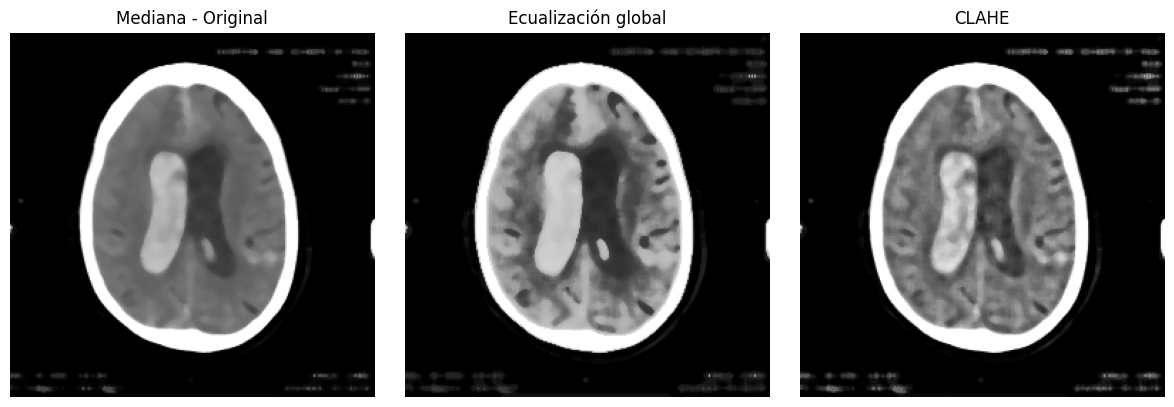

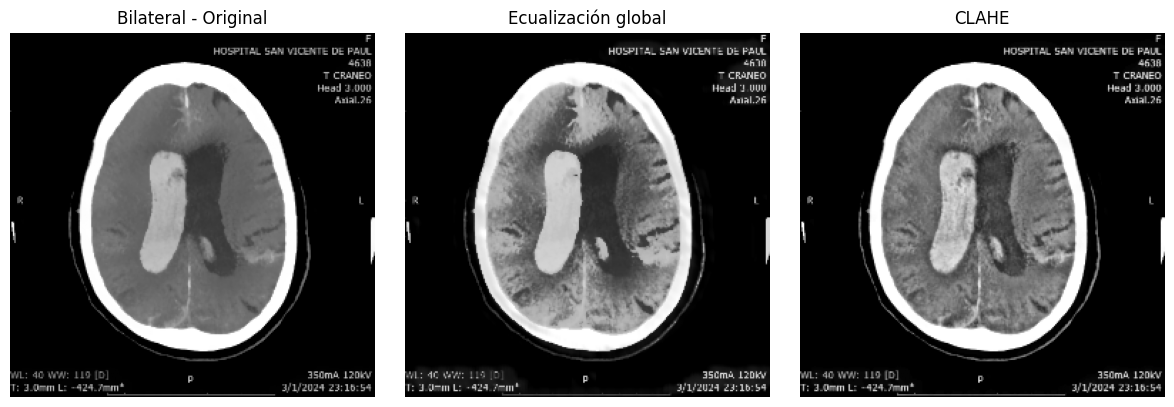

In [83]:
from skimage import exposure
import matplotlib.pyplot as plt
import numpy as np

imagenes = {
    #"Original": img,
    #"Media": img_mean,
    "Mediana": img_median,
    #"Gaussiana": img_gauss,
    "Bilateral": img_bilat,
    #"Wavelet": img_wave
}
for nombre, im in imagenes.items():

    # Normalizar a [0,1]
    im_norm = im.astype(np.float32)
    if im_norm.max() > 1:
        im_norm /= 255.0

    # Ecualizaciones
    im_eq = exposure.equalize_hist(im_norm)
    im_clahe = exposure.equalize_adapthist(im_norm, clip_limit=0.03,  kernel_size=(8, 8) )

    # Mostrar imágenes
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(im_norm, cmap="gray")
    plt.title(f"{nombre} - Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(im_eq, cmap="gray")
    plt.title("Ecualización global")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(im_clahe, cmap="gray")
    plt.title("CLAHE")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

#------------------------------------------------------------------------------
#Conclusión: La ecualización CLAHE mejora significativamente el contraste de la imagen del cráneo
#------------------------------------------------------------------------------      




C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_16712\857994664.py:23: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  head = remove_small_holes(head, area_threshold=5000)
C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_16712\857994664.py:24: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  craneo 

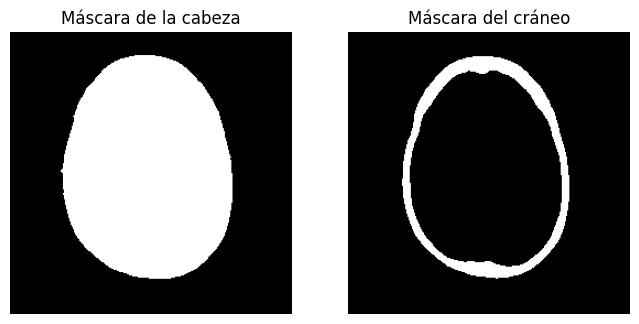

In [84]:
#Creación de la máscara de la región del cerebro y cráneo dado que con un umbral se lo puede separar

from skimage.measure import label, regionprops
from skimage.morphology import erosion, disk, remove_small_holes

# --- 1) Umbral simple ---
head_mask = img > 0.05
craneo_mask = img > 0.95

# --- 2) Componente más grande (cabeza) ---
lab_head = label(head_mask, connectivity=2)
props_head = regionprops(lab_head)
largest = max(props_head, key=lambda p: p.area)
head = lab_head == largest.label

# --- 2) Componente más grande (craneo) ---
lab_craneo = label(craneo_mask, connectivity=2)
props_craneo = regionprops(lab_craneo)
largest = max(props_craneo, key=lambda p: p.area)
craneo = lab_craneo == largest.label

# --- 3) Rellenar huecos ---
head = remove_small_holes(head, area_threshold=5000)
craneo = remove_small_holes(craneo, area_threshold=5000)

# --- 4) Erosión para quitar cráneo ---
ERODE_SKULL_RADIUS = 10
brain_roi = erosion(head, disk(ERODE_SKULL_RADIUS))
brain_roi = remove_small_holes(brain_roi, area_threshold=2000)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(head, cmap="gray"); plt.title("Máscara de la cabeza"); plt.axis("off");
plt.subplot(1,2,2); plt.imshow(craneo, cmap="gray"); plt.title("Máscara del cráneo"); plt.axis("off");
plt.plot();

Segmentación con Otsu

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].



Imagen: CLAHE Mediana
Segmentación: Otsu en ROI
Umbral Otsu: 0.6165
Objetos detectados: 7
Área promedio (px): 1005.86


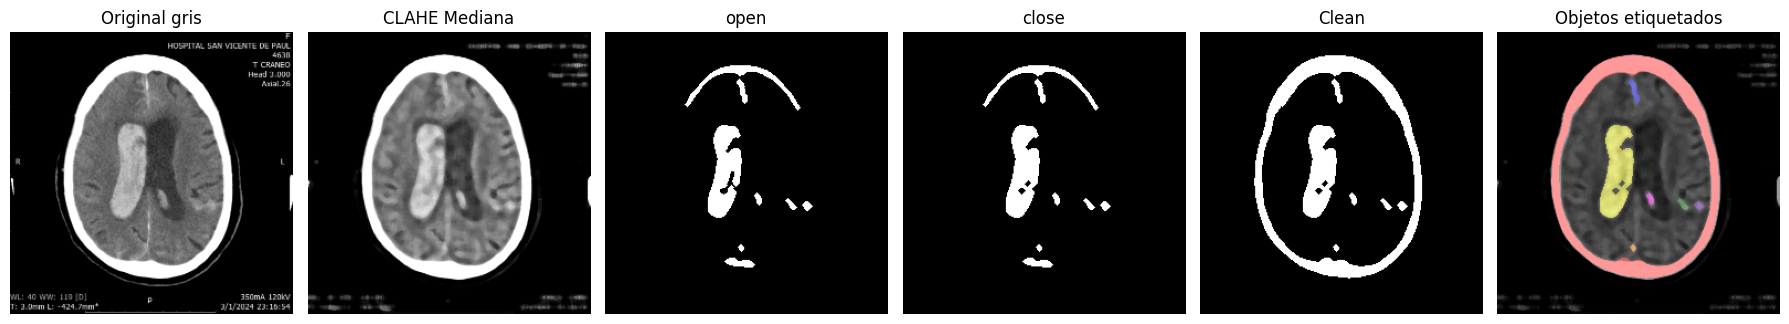

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].



Imagen: CLAHE Bilateral
Segmentación: Otsu en ROI
Umbral Otsu: 0.6099
Objetos detectados: 6
Área promedio (px): 1138.67


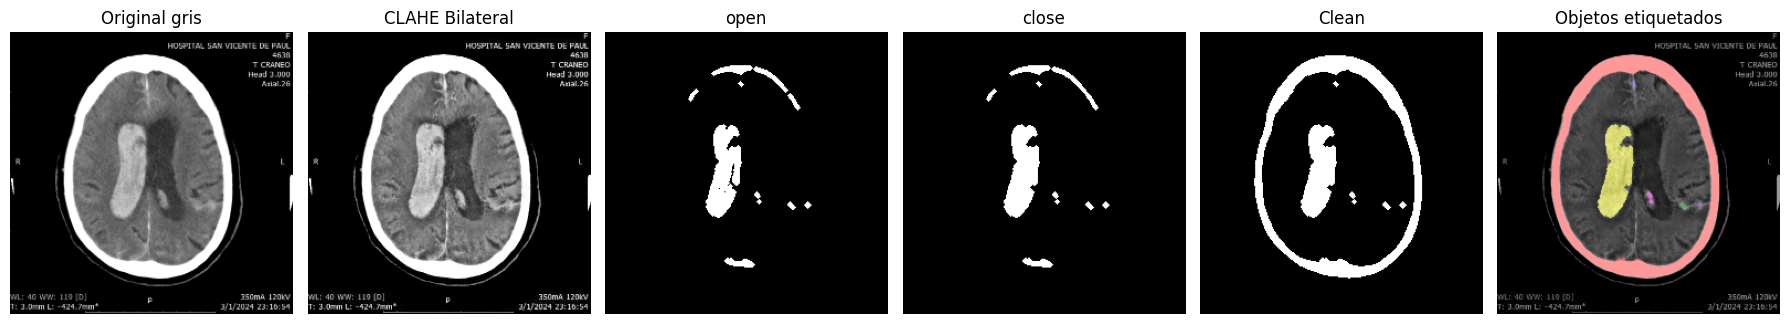

In [85]:
#Segmentacion Otsu
from skimage.measure import label, regionprops
from skimage.transform import resize
from skimage import exposure
from skimage.filters import threshold_otsu
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import disk, opening, closing, remove_small_objects, remove_small_holes
from skimage.color import label2rgb

# Diccionario de imágenes a probar
imagenes = {
    "CLAHE Mediana": exposure.equalize_adapthist(img_median, clip_limit=0.03, kernel_size=(8, 8)),
    "CLAHE Bilateral": exposure.equalize_adapthist(img_bilat, clip_limit=0.03, kernel_size=(8, 8))
    }

for nombre, img_in in imagenes.items():

    # Normalizar tamaño y tipo
    img_proc = resize(img_in, (256, 256), anti_aliasing=True).astype(np.float32)

    roi_vals = img_proc[brain_roi] # brain_roi
    if roi_vals.size == 0:
        print(f"{nombre}: ROI vacía")
        continue


    T = threshold_otsu(roi_vals)
    bw = (img_proc > T) & brain_roi 

    se = disk(2) #2

    bw_open    = opening(bw, se)
    bw_close  = closing(bw_open, se)

    clean = np.logical_or(bw_open, bw_close)       # OR entre open y close
    clean = np.logical_or(clean,craneo )           # OR clean y máscara del cráneo

    lab = label(clean, connectivity=2)
    props = regionprops(lab, intensity_image=img_proc)

    colored = label2rgb(
        lab,
        image=img_proc,   # fondo en gris
        bg_label=0,
        alpha=0.4         # transparencia del color
    )

    # -------- Reporte --------
    areas = [p.area for p in props] if props else []
    mean_area = np.mean(areas) if areas else 0

    print("\n==============================")
    print(f"Imagen: {nombre}")
    print("Segmentación: Otsu en ROI")
    print(f"Umbral Otsu: {T:.4f}")
    print("Objetos detectados:", len(props))
    print("Área promedio (px):", round(mean_area, 2))
    print("==============================")

    # -------- VISUALIZACIÓN --------
    plt.figure(figsize=(18,4))
    plt.subplot(1,6,1);    plt.imshow(img, cmap="gray");    plt.title("Original gris");    plt.axis("off")
    plt.subplot(1,6,2);    plt.imshow(img_proc, cmap="gray");    plt.title(nombre);    plt.axis("off")
    plt.subplot(1,6,3);    plt.imshow(bw_open, cmap="gray");    plt.title("open");    plt.axis("off")    
    plt.subplot(1,6,4);    plt.imshow(bw_close, cmap="gray");    plt.title("close");    plt.axis("off")
    plt.subplot(1,6,5);    plt.imshow(clean, cmap="gray");    plt.title("Clean");    plt.axis("off")
    plt.subplot(1,6,6)
    plt.imshow(colored)
    plt.title("Objetos etiquetados")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
